In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple
from matplotlib.dates import date2num
from statsmodels.tsa.seasonal import seasonal_decompose
import datetime
from datacube.utils.geometry import Geometry, CRS 
import geopandas as gpd

from pymannkendall.pymannkendall import (
    __preprocessing,
    __missing_values_analysis,
    __mk_score,
    __variance_s,
    __z_score,
    __p_value,
    sens_slope,
)

## 1. Load and prepare WIT data 
An output of the WIT tool is a csv file which we will use to detect change at the site. Add the file name into the line that says "ACTION". The 'date' column will be converted so it is able to be read for time series operations such as plotting and ordered into chronological order. 

Detected 4 abrupt change points in WATER residuals.


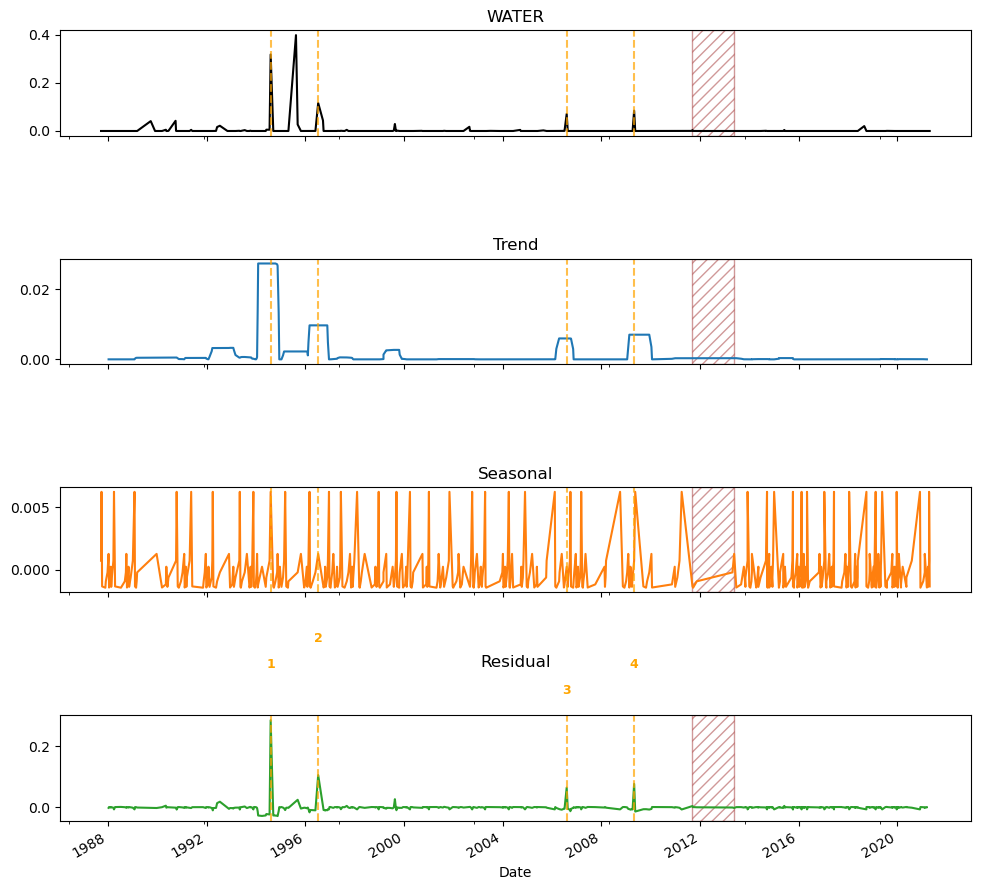

In [14]:
csv_path = "178.csv"      # ACTION: Add CSV output form WIT tool - generates in .../DEA_products/...
component = "WATER"       #  CHANGE THIS to the component you want to analyze (e.g. "PV", "GV", "NPV" "WET", "WATER")

# Load and prepare data 
df = pd.read_csv(csv_path)
df["TIME"] = pd.to_datetime(df["TIME"])
df = df.sort_values("TIME").reset_index(drop=True)

# Function: Mark low-quality data periods 
def generate_low_quality_data_periods(df):
    df = df.copy()
    df["off_value"] = 0

    # Landsat 5–8 SLC-off gap
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)
    df.loc[
        (df["TIME"] >= LS5_8_gap_start) & (df["TIME"] <= LS5_8_gap_end),
        "off_value",
    ] = 100

    # Low observation density (less than 4 in 365 days)
    for i in range(3, len(df) - 3):
        if (df.loc[i + 3, "TIME"] - df.loc[i, "TIME"]).days > 365:
            df.loc[
                (df["TIME"] >= df.loc[i, "TIME"])
                & (df["TIME"] <= df.loc[i + 3, "TIME"]),
                "off_value",
            ] = 100
    return df

# Add low-quality flags
df = generate_low_quality_data_periods(df)

#  Extract selected component 
if component not in df.columns:
    raise ValueError(f"Component '{component}' not found in CSV columns: {list(df.columns)}")

pv = df.set_index("TIME")[component].astype(float)

# Identify low-quality data ranges 
low_quality_ranges = []
mask = df["off_value"] == 100
if mask.any():
    grouped = (mask != mask.shift()).cumsum()
    for _, group in df[mask].groupby(grouped):
        start, end = group["TIME"].iloc[0], group["TIME"].iloc[-1]
        low_quality_ranges.append((start, end))

#  Filter large gaps 
gaps = pv.index.to_series().diff().dt.days
pv_filtered = pv.loc[gaps.fillna(1) < 60]

 
if len(pv_filtered) < 24:
    print(f"Not enough data for {component}, skipping.")
else:
    result = seasonal_decompose(pv_filtered, model="additive", period=12)
    trend, seasonal, resid = result.trend, result.seasonal, result.resid

    # Detect abrupt changes 
    threshold = 2 * resid.std() #2 standard diviations form the mean
    change_points = resid[abs(resid) > threshold].index
    print(f"Detected {len(change_points)} abrupt change points in {component} residuals.")

    # Plot 
    fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
    pv.plot(ax=axes[0], title=f"{component}", color="black")
    trend.plot(ax=axes[1], title="Trend", color="tab:blue")
    seasonal.plot(ax=axes[2], title="Seasonal", color="tab:orange")
    resid.plot(ax=axes[3], color="tab:green")
    axes[3].set_title("Residual", pad=35)

    # Shade low-quality data
    for ax in axes:
        for start, end in low_quality_ranges:
            ax.axvspan(start, end, facecolor="none", edgecolor="darkred", hatch="///", alpha=0.4)

    # Mark change points
    change_points_sorted = sorted(change_points)
    for idx, cp in enumerate(change_points_sorted, start=1):
        for ax in axes:
            ax.axvline(cp, color="orange", linestyle="--", alpha=0.7)

        # Alternate label positions
        mod = idx % 3
        y_pos = resid.max() * (1.3 + 0.3 * mod)
        axes[3].text(
            cp,
            y_pos,
            str(idx),
            color="orange",
            fontsize=9,
            fontweight="bold",
            ha="center",
            rotation=0,
            clip_on=False,
        )

    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()

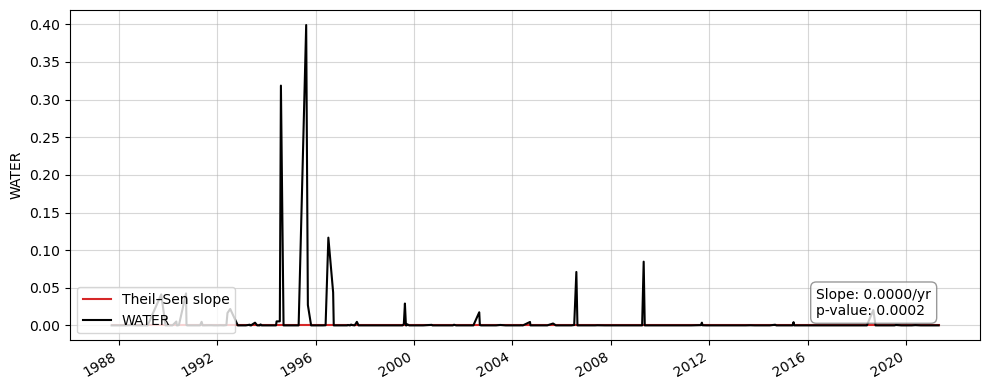

In [15]:
def mk_with_slopes(y, alpha=0.05):
    """
    This function checks the Mann-Kendall (MK) test (Mann 1945, Kendall 1975, Gilbert 1987).
    Modified from pymannkendall to return fewer statistics.
    """
    res = namedtuple('Mann_Kendall_Test', ['p', 'slope', 'intercept'])
    x, c = __preprocessing(y)
    x, n = __missing_values_analysis(x, method='skip')
    
    s = __mk_score(x, n)
    var_s = __variance_s(x, n)
    z = __z_score(s, var_s)
    p, h, trend = __p_value(z, alpha)
    slope, intercept = sens_slope(y)
    return res(p, slope, intercept)

# === Run Mann-Kendall on selected component ===
p, slope, intercept = mk_with_slopes(df[component])

# === Plot ===
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

# Theil–Sen line
y = np.arange(len(df[component])) * slope + intercept
ax.plot(date2num(df["TIME"]), y, color='tab:red', label='Theil–Sen slope')

# Component time series
df.plot(x="TIME", y=component, ax=ax, label=component, color="black")

ax.set_ylabel(component)
ax.set_xlabel(None)
ax.grid(alpha=0.5)

# Annotate slope and p-value
textstr = f"Slope: {slope*12:.4f}/yr\np-value: {p:.4f}"
ax.text(
    0.82, 0.16, textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
)

ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

Limitations
- The national bushfires layer did not include the major bushfire of 2003. Due to my lack of expertese in the area I would have analysed this at face value instead of realsing there was a issue with the underlying data. This meant I could not fully rely on the layer to be able to communicate the 'why'.

- 

In [29]:
print(ds)


<xarray.Dataset> Size: 187kB
Dimensions:       (y: 93, x: 83)
Coordinates:
    time          datetime64[ns] 8B 2006-08-12T23:49:52.511390
  * y             (y) float64 744B -3.979e+06 -3.979e+06 ... -3.982e+06
  * x             (x) float64 664B 1.514e+06 1.514e+06 ... 1.517e+06 1.517e+06
    spatial_ref   int32 4B 3577
Data variables:
    nbart_blue    (y, x) float32 31kB 651.0 834.0 802.0 657.0 ... 6.0 31.0 23.0
    nbart_green   (y, x) float32 31kB 883.0 996.0 1.004e+03 ... 267.0 267.0
    nbart_red     (y, x) float32 31kB 1.111e+03 1.302e+03 ... 389.0 334.0
    nbart_nir     (y, x) float32 31kB 2.012e+03 2.028e+03 ... 2.173e+03
    nbart_swir_1  (y, x) float32 31kB 1.753e+03 1.564e+03 ... 1.138e+03
    nbart_swir_2  (y, x) float32 31kB 1.276e+03 1.124e+03 ... 542.0 574.0
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref


Finding datasets
    ga_ls8c_ard_3
    ga_ls7e_ard_3 (ignoring SLC-off observations)
    ga_ls5t_ard_3
Applying fmask pixel quality/cloud mask
Returning 3 time steps as a dask array
✅ Saved: validation_images/change_3_before.png
✅ Saved: validation_images/change_3_after.png


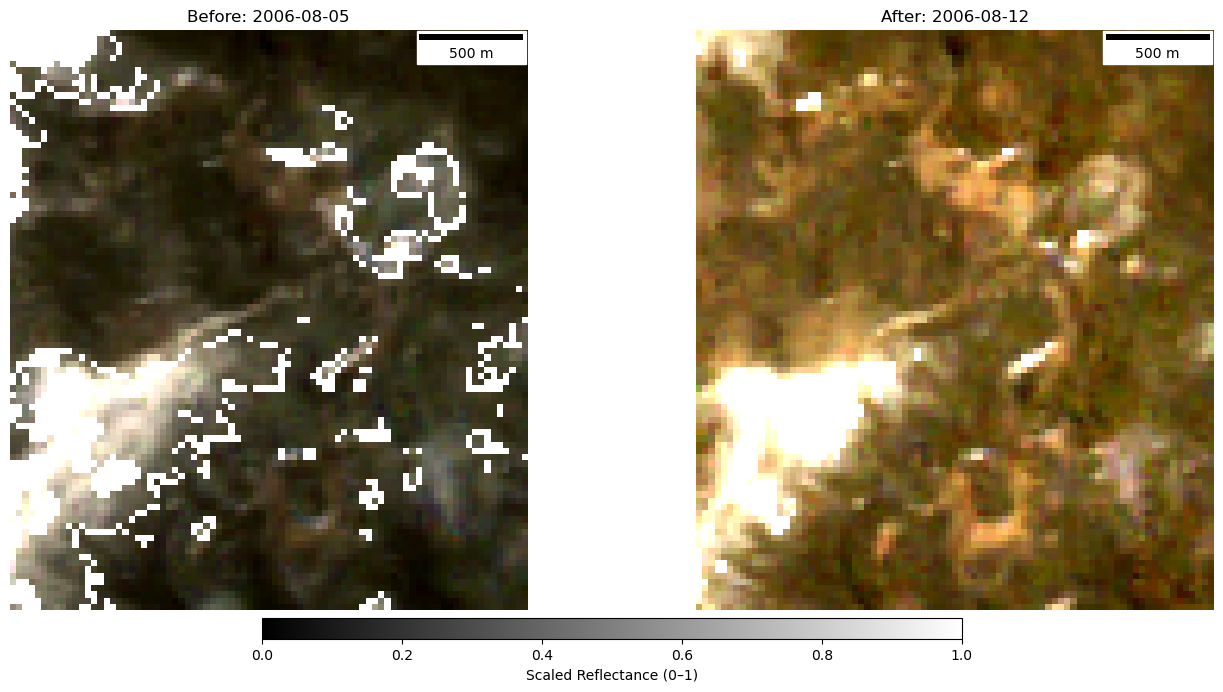

✅ Saved PNG: validation_images/change_3_before_after.png


In [32]:

# Validation: pull satellite images around a selected change

import os
import numpy as np
import geopandas as gpd
from datetime import timedelta
from datacube import Datacube
from datacube.utils.geometry import Geometry, CRS
from odc.algo import mask_cleanup  # optional, only if you use it later
from dea_tools.datahandling import load_ard  # adjust if your environment exposes load_ard elsewhere
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib_scalebar.scalebar import ScaleBar 
from matplotlib.colors import Normalize
# Build a change table from detected change points 
# change_points_sorted was created earlier from resid thresholding
change_dates = change_points_sorted  # these are Timestamp objects
change_df = pd.DataFrame({
    "ID": range(1, len(change_dates) + 1),
    "Date": pd.to_datetime(change_dates)
})

# Parameters: adjust as needed
polygon_path = "ginini_flats.shp"   # ACTION: change this if your polygon file has another name
change_id_to_validate = 3           # ACTION: which change ID from the graph/table
time_window_days = 15               # how many days before/after to search for imagery

# read polygon
poly = gpd.read_file(polygon_path)

# Ensure CRS is defined (use the same projection as WIT)
if poly.crs is None:
    # assume EPSG:3577 if your polygon was in projected coords; otherwise use EPSG:4326
    poly = poly.set_crs("EPSG:3577")

# Convert to datacube geometry (single polygon assumed)
gpgon = Geometry(poly.geometry[0], CRS(str(poly.crs)))

# locate the change event in change_df
selected_change = change_df.loc[change_df["ID"] == change_id_to_validate]
if selected_change.empty:
    raise ValueError(f"No change found with ID {change_id_to_validate}. Available IDs: {list(change_df['ID'])}")

change_date = pd.to_datetime(selected_change["Date"].values[0])

# time window strings for load_ard
time_before = (change_date - timedelta(days=time_window_days)).strftime("%Y-%m-%d")
time_after  = (change_date + timedelta(days=time_window_days)).strftime("%Y-%m-%d")

# Bands to load (NBART names)
bands = [f"nbart_{b}" for b in ("blue", "green", "red", "nir", "swir_1", "swir_2")]

# Open datacube & load ARD
dc = Datacube(app="change_validation")
ds = load_ard(
    dc,
    products=["ga_ls8c_ard_3", "ga_ls7e_ard_3", "ga_ls5t_ard_3"],
    ls7_slc_off=False,
    measurements=bands,
    geopolygon=gpgon,
    output_crs="EPSG:3577",
    resolution=(-30, 30),
    resampling={"fmask": "nearest", "*": "bilinear"},
    time=(time_before, time_after),
    group_by="solar_day",
    dask_chunks={"time": 1, "x": 2048, "y": 2048},
)

# load into memory (optional depending on dataset size)
ds = ds.load()

# make output folder
out_folder = "validation_images"
os.makedirs(out_folder, exist_ok=True)

# handle edge cases: no images found
if "time" not in ds.coords or len(ds.time) == 0:
    raise ValueError(f"No satellite scenes found between {time_before} and {time_after} for polygon {polygon_path}")

time_values = ds.time.values  # numpy datetime64 array

# choose nearest pre/post images relative to change_date
target_pre = np.datetime64(change_date - timedelta(days=1))
target_post = np.datetime64(change_date + timedelta(days=1))

# compute nearest indices safely
absdiff_pre = np.abs(time_values - target_pre)
absdiff_post = np.abs(time_values - target_post)
closest_pre_idx = int(absdiff_pre.argmin())
closest_post_idx = int(absdiff_post.argmin())

# If pre and post resolve to the same scene (e.g., only one scene), handle gracefully
if closest_pre_idx == closest_post_idx:
    # try to find the next best candidate for post (or pre)
    if len(time_values) > 1:
        # pick the one before for pre (if available) and after for post
        sorted_idx = np.argsort(np.abs(time_values - np.datetime64(change_date)))
        # ensure at least two unique indices
        first, second = int(sorted_idx[0]), int(sorted_idx[1])
        closest_pre_idx, closest_post_idx = min(first, second), max(first, second)
    else:
        print("Warning: only one scene available in the time window; using same scene as pre and post.")

pre_ds = ds.isel(time=closest_pre_idx)
post_ds = ds.isel(time=closest_post_idx)

for ds in [pre_ds, post_ds]:
    if "time" in ds:
        ds["time"].attrs.pop("units", None)
        ds["time"].attrs.pop("calendar", None)

def save_dataset_as_png(ds, path, band_name=None):
    """Convert an xarray Dataset/DataArray to a PNG."""
    if isinstance(ds, xr.Dataset):
        if band_name is None:
            band_name = list(ds.data_vars)[0]  # pick first band if not specified
        da = ds[band_name]
    else:
        da = ds

    img = da.values
    img = np.nan_to_num(img, nan=0)

    # Contrast stretch 2–98%
    img_min, img_max = np.percentile(img, [2, 98])
    img = np.clip((img - img_min) / (img_max - img_min), 0, 1)

    plt.imsave(path, img, cmap="viridis")
    print(f"✅ Saved: {path}")

# File paths
pre_png = os.path.join(out_folder, f"change_{change_id_to_validate}_before.png")
post_png = os.path.join(out_folder, f"change_{change_id_to_validate}_after.png")

# Save as PNGs (you can specify band_name="nbart_nir" or similar)
save_dataset_as_png(pre_ds, pre_png, band_name="nbart_red")
save_dataset_as_png(post_ds, post_png, band_name="nbart_red")

pre_date = np.datetime_as_string(pre_ds.time.values, unit='D')
post_date = np.datetime_as_string(post_ds.time.values, unit='D')

# --- Load before/after datasets ---
before_path = "validation_images/change_3_before.nc"
after_path  = "validation_images/change_3_after.nc"

before_ds = xr.open_dataset(before_path)
after_ds  = xr.open_dataset(after_path)

# --- Extract image dates ---
before_date = pd.to_datetime(before_ds.time.values)
after_date  = pd.to_datetime(after_ds.time.values)

# --- Function to make RGB (with scaling!) ---
def make_rgb(ds, stretch=(0.02, 0.98)):
    """Create RGB from nbart_red/green/blue bands with reflectance scaling."""
    r = ds.nbart_red.values.astype(float) / 10000.0
    g = ds.nbart_green.values.astype(float) / 10000.0
    b = ds.nbart_blue.values.astype(float) / 10000.0

    # Clip bad values
    r, g, b = np.clip(r, 0, 1), np.clip(g, 0, 1), np.clip(b, 0, 1)

    # Apply percentile stretch
    vmin = np.nanpercentile([r, g, b], stretch[0]*100)
    vmax = np.nanpercentile([r, g, b], stretch[1]*100)
    rgb = np.dstack([(r - vmin) / (vmax - vmin),
                     (g - vmin) / (vmax - vmin),
                     (b - vmin) / (vmax - vmin)])
    rgb = np.clip(rgb, 0, 1)
    return rgb

# --- Make RGBs ---
before_rgb = make_rgb(before_ds)
after_rgb = make_rgb(after_ds)

# --- Plot side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
titles = [f"Before: {before_date.date()}", f"After: {after_date.date()}"]
rgbs = [before_rgb, after_rgb]

for ax, rgb, title in zip(axes, rgbs, titles):
    im = ax.imshow(rgb)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

    # Optional scale bar
    try:
        scalebar = ScaleBar(30, "m", length_fraction=0.25)
        ax.add_artist(scalebar)
    except Exception:
        pass

# Add legend
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])
norm = Normalize(vmin=0, vmax=1)
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="gray"),
                    cax=cbar_ax, orientation='horizontal')
cbar.set_label("Scaled Reflectance (0–1)", fontsize=10)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

# --- Save as PNG ---
os.makedirs("validation_images", exist_ok=True)
out_png = os.path.join("validation_images", "change_3_before_after.png")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
print(f"✅ Saved PNG: {out_png}")


In [25]:
!pip install matplotlib-scalebar


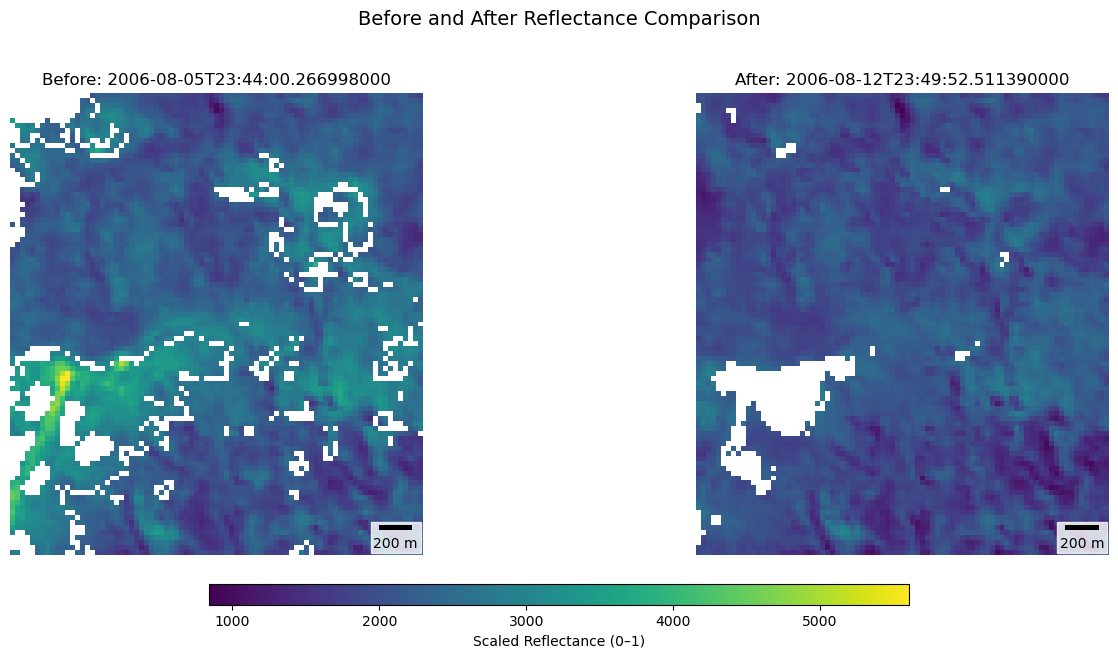

✅ Saved: ./validation_images/change_3_comparison.png


In [39]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib_scalebar.scalebar import ScaleBar

# ===============================================================
# INPUTS
# ===============================================================
out_folder = "./validation_images"  # your output folder
change_id_to_validate = 3           # ID of change being validated

# Example file paths
before_path = os.path.join(out_folder, f"change_{change_id_to_validate}_before.nc")
after_path  = os.path.join(out_folder, f"change_{change_id_to_validate}_after.nc")

# ===============================================================
# OPEN DATASETS
# ===============================================================
before_ds = xr.open_dataset(before_path)
after_ds  = xr.open_dataset(after_path)

# Select your variable (replace with correct band name or computation)
# Example: nbart_nir, nbart_red, NDVI, etc.
var_name = "nbart_nir"  # Change this to whichever band or variable you want

# Your datasets do NOT have time dimension
before_data = before_ds[var_name]
after_data  = after_ds[var_name]

# Extract dates (if stored in the dataset attributes or coords)
before_date = str(before_ds.time.values) if "time" in before_ds else "Unknown date"
after_date  = str(after_ds.time.values) if "time" in after_ds else "Unknown date"

# ===============================================================
# PLOTTING
# ===============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
titles = [f"Before: {before_date}", f"After: {after_date}"]
datasets = [before_data, after_data]

# Shared normalization (ensures consistent color scale)
vmin = float(np.nanmin([before_data.min(), after_data.min()]))
vmax = float(np.nanmax([before_data.max(), after_data.max()]))
norm = Normalize(vmin=vmin, vmax=vmax)

for ax, data, title in zip(axes, datasets, titles):
    im = ax.imshow(data, cmap="viridis", norm=norm)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

    # Add scale bar (approximate pixel size)
    try:
        res_x = abs(before_ds.rio.resolution()[0])
    except:
        res_x = 10  # fallback if rio not available
    scalebar = ScaleBar(res_x, units="m", location="lower right", box_color="white", box_alpha=0.8)
    ax.add_artist(scalebar)

# ===============================================================
# COLORBAR
# ===============================================================
cbar_ax = fig.add_axes([0.25, 0.1, 0.5, 0.03])
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"),
                    cax=cbar_ax, orientation='horizontal')
cbar.set_label("Scaled Reflectance (0–1)", fontsize=10)

# ===============================================================
# FINAL TOUCHES
# ===============================================================
fig.suptitle("Before and After Reflectance Comparison", fontsize=14, y=0.95)
plt.tight_layout(rect=[0, 0.15, 1, 0.93])

# ===============================================================
# SAVE PNG
# ===============================================================
png_path = os.path.join(out_folder, f"change_{change_id_to_validate}_comparison.png")
plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Saved: {png_path}")